In [2]:
pip install tensorflow


   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
    --------------------------------------- 0.3/14.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.6 MB 2.6 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/14.6 MB 2.6 MB/s eta 0:00:06
   ----- ---------------------------------- 2.1/14.6 MB 2.7 MB/s eta 0:00:05
   ------- -------------------------------- 2.6/14.6 MB 2.7 MB/s eta 0:00:05
   -------- ------------------------------- 3.1/14.6 MB 2.7 MB/s eta 0:00:05
   ---------- ----------------------------- 3.7/14.6 MB 2.7 MB/s eta 0:00:05
   ---------- ----------------------------- 3.9/14.6 MB 2.6 MB/s eta 0:00:05
   ----------- ---------------------------- 4.2/14.6 MB 2.4 MB/s eta 0:00:05
   ------------ --------------------------- 4.5/14.6 MB 2.2 MB/s eta 0:00:05
   ------------ --------------------------- 4.7/14.6 MB 2.1 MB/s eta 0:00:05
   ------------- -------------------------- 5.0/14.6 MB 2.1 MB/s eta 0:00:05
   ---------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
argilla 1.6.0 requires httpx<0.24,>=0.15, but you have httpx 0.28.1 which is incompatible.
basemap 1.3.6 requires matplotlib<3.7,>=1.5; python_version >= "3.5", but you have matplotlib 3.10.0 which is incompatible.
gpt-index 0.6.2 requires requests<2.30.0, but you have requests 2.32.3 which is incompatible.
langchain 0.0.163 requires pydantic<2,>=1, but you have pydantic 2.10.6 which is incompatible.
langchain-community 0.3.16 requires langchain<0.4.0,>=0.3.16, but you have langchain 0.0.163 which is incompatible.
torchvision 0.15.2 requires torch==2.0.1, but you have torch 2.4.1 which is incompatible.


In [ ]:
#Image classication problem --Take (Model , Train, Classiy)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [3]:
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).with_suffix('')

228813984/228813984 [==============================] - 129s 1us/step


In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


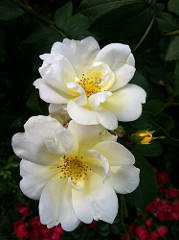

In [5]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

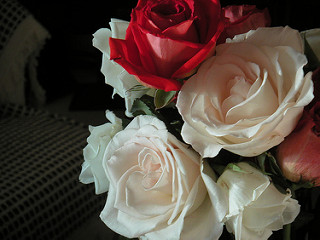

In [6]:
PIL.Image.open(str(roses[1]))

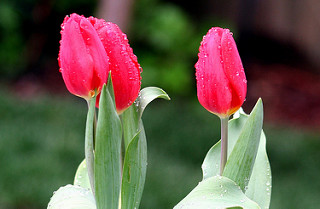

In [7]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [8]:
batch_size = 32
img_height = 180
img_width = 180

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [11]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


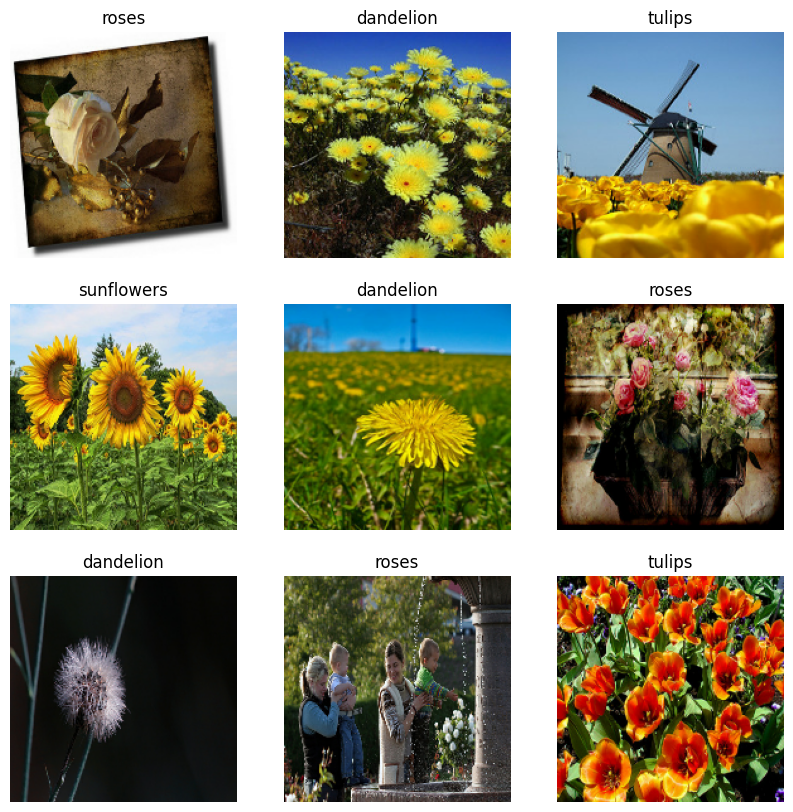

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [13]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [15]:
normalization_layer = layers.Rescaling(1./255)

In [16]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [17]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [18]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 90, 90, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 45, 45, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        1

In [20]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
92/92 [==============================] - 98s 1s/step - loss: 1.3555 - accuracy: 0.4254 - val_loss: 1.0962 - val_accuracy: 0.5354
Epoch 2/10
92/92 [==============================] - 60s 656ms/step - loss: 0.9680 - accuracy: 0.6172 - val_loss: 0.9349 - val_accuracy: 0.6431
Epoch 3/10
92/92 [==============================] - 61s 668ms/step - loss: 0.7329 - accuracy: 0.7272 - val_loss: 0.8868 - val_accuracy: 0.6526
Epoch 4/10
92/92 [==============================] - 62s 669ms/step - loss: 0.5204 - accuracy: 0.8120 - val_loss: 0.9497 - val_accuracy: 0.6540
Epoch 5/10
92/92 [==============================] - 63s 685ms/step - loss: 0.3120 - accuracy: 0.9002 - val_loss: 1.1445 - val_accuracy: 0.6553
Epoch 6/10
92/92 [==============================] - 70s 767ms/step - loss: 0.1892 - accuracy: 0.9377 - val_loss: 1.3213 - val_accuracy: 0.6349
Epoch 7/10
92/92 [==============================] - 60s 654ms/step - loss: 0.1304 - accuracy: 0.9629 - val_loss: 1.4239 - val_accuracy: 0.6417
Ep

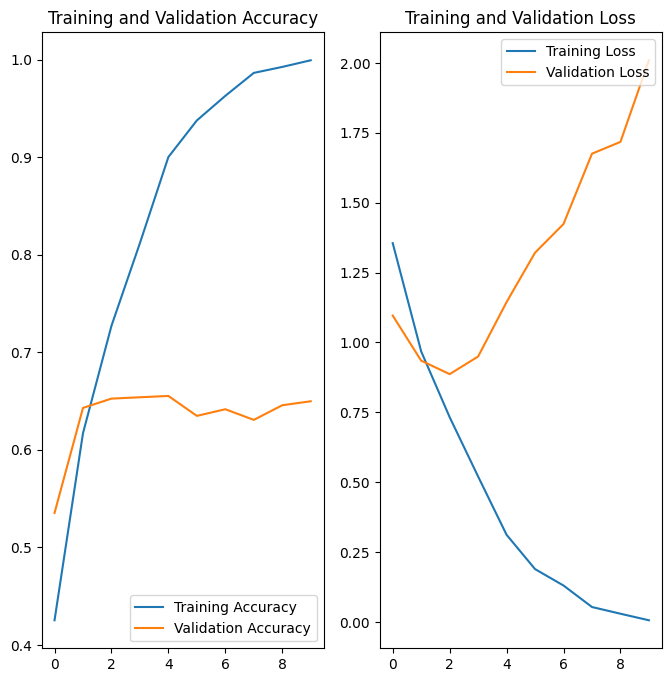

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [22]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 430ms/step
This image most likely belongs to roses with a 85.69 percent confidence.
